In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def leaky_relu(x, alpha=0.01):
    return np.maximum(alpha * x, x)

In [3]:
def leaky_relu_grad(x, alpha=0.01):
    return np.where(x < 0, alpha, 1)

In [4]:
x = np.linspace(-5, 5, 200)
y = leaky_relu(x)
dy = leaky_relu_grad(x)

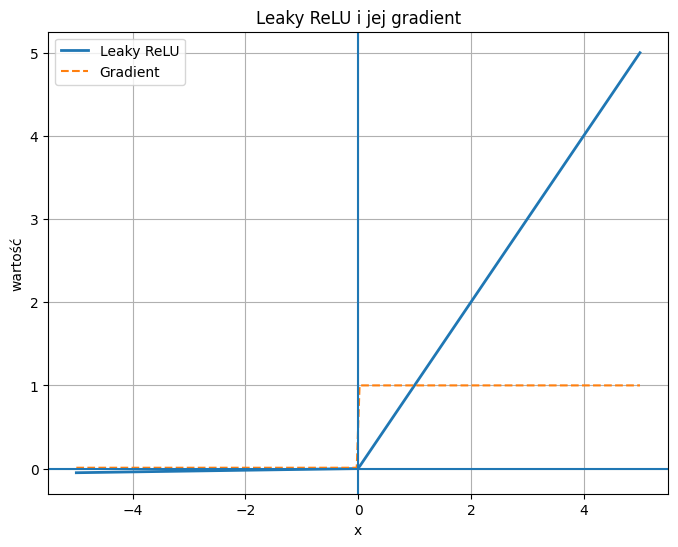

In [5]:
plt.figure(figsize=(8, 6))

plt.plot(x, y, label="Leaky ReLU", linewidth=2)
plt.plot(x, dy, label="Gradient", linestyle='--')

plt.axhline(0)
plt.axvline(0)

plt.title("Leaky ReLU i jej gradient")
plt.xlabel("x")
plt.ylabel("wartość")

plt.legend()
plt.grid(True)

plt.show()

In [6]:
def leaky_relu(x, alpha):
    return np.maximum(alpha * x, x)

In [7]:
x = np.linspace(-5, 5, 200)

alphas = [0.001, 0.01, 0.1]

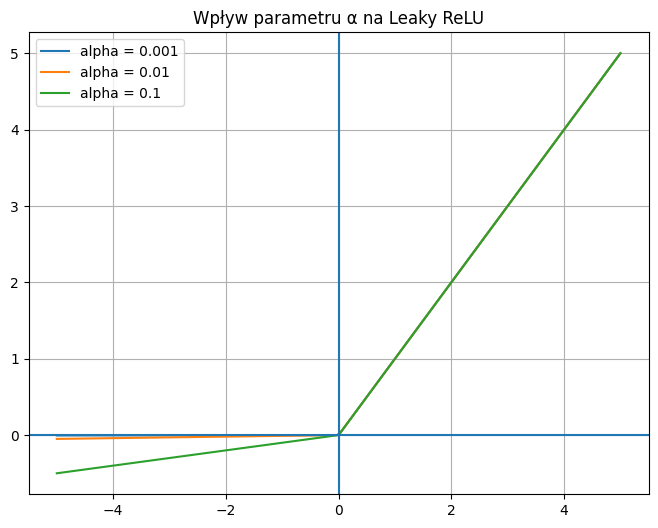

In [8]:
plt.figure(figsize=(8,6))

for alpha in alphas:
    y = leaky_relu(x, alpha)
    plt.plot(x, y, label=f'alpha = {alpha}')

plt.axhline(0)
plt.axvline(0)

plt.title("Wpływ parametru α na Leaky ReLU")
plt.legend()
plt.grid(True)

plt.show()

In [12]:
def f(x):
    return leaky_relu(x, 0.01)**2

In [13]:
def grad_f(x, alpha=0.01):
    return 2 * leaky_relu(x, alpha) * leaky_relu_grad(x, alpha)

In [14]:
x = 3.0
alpha_lr = 0.1

trajectory = [x]

for _ in range(15):
    x = x - alpha_lr * grad_f(x)
    trajectory.append(x)

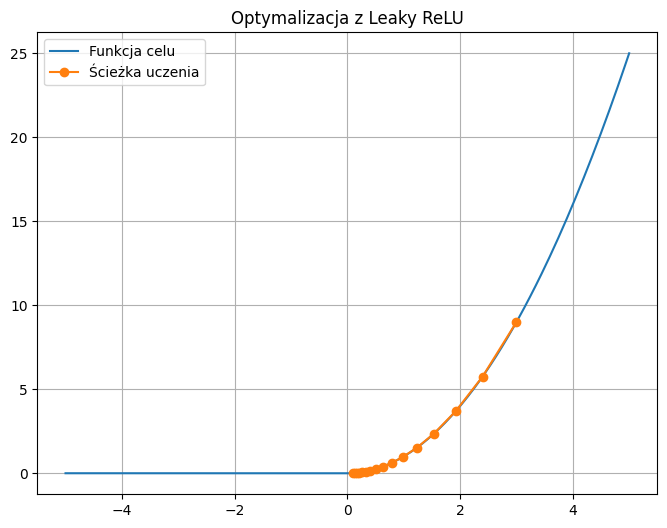

In [15]:
x_vals = np.linspace(-5, 5, 200)
y_vals = f(x_vals)

plt.figure(figsize=(8,6))

plt.plot(x_vals, y_vals, label="Funkcja celu")
plt.plot(trajectory, [f(x) for x in trajectory], 'o-', label="Ścieżka uczenia")

plt.legend()
plt.grid(True)
plt.title("Optymalizacja z Leaky ReLU")

plt.show()

In [16]:
def leaky_relu(x, alpha=0.01):
    return np.maximum(alpha * x, x)

def leaky_relu_grad(x, alpha=0.01):
    return np.where(x < 0, alpha, 1)

In [17]:
def f(v, alpha=0.01):
    x, y = v
    return leaky_relu(x, alpha)**2 + leaky_relu(y, alpha)**2

In [18]:
def grad_f(v, alpha=0.01):
    x, y = v
    
    dx = 2 * leaky_relu(x, alpha) * leaky_relu_grad(x, alpha)
    dy = 2 * leaky_relu(y, alpha) * leaky_relu_grad(y, alpha)
    
    return np.array([dx, dy])

In [19]:
x0 = np.array([3.0, -3.0])
alpha_lr = 0.1
n_iter = 15

path = [x0.copy()]

In [20]:
x = x0.copy()

for _ in range(n_iter):
    x = x - alpha_lr * grad_f(x)
    path.append(x.copy())

path = np.array(path)

In [21]:
x_vals = np.linspace(-4, 4, 200)
y_vals = np.linspace(-4, 4, 200)

X, Y = np.meshgrid(x_vals, y_vals)

Z = leaky_relu(X)**2 + leaky_relu(Y)**2

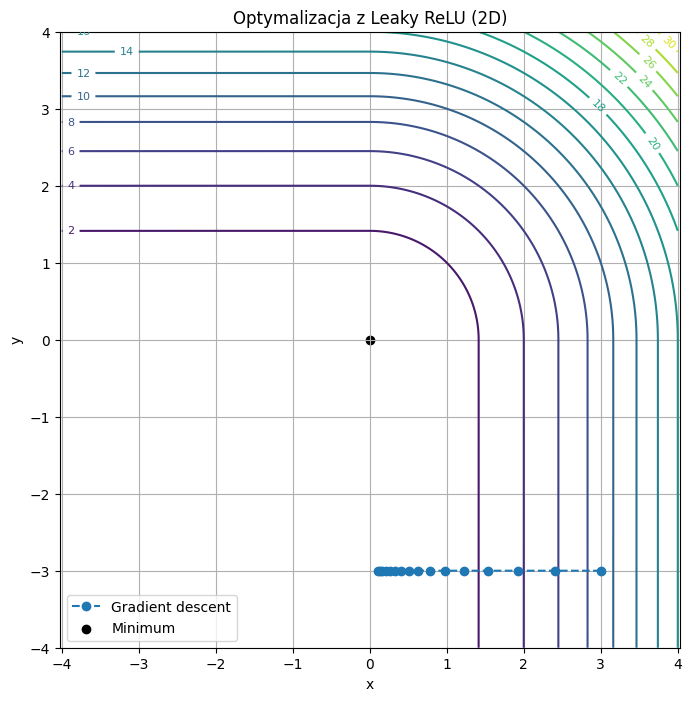

In [22]:
plt.figure(figsize=(8,8))

contours = plt.contour(X, Y, Z, levels=20)
plt.clabel(contours, inline=True, fontsize=8)

plt.plot(path[:,0], path[:,1], 'o--', label='Gradient descent')
plt.scatter(0, 0, color='black', label='Minimum')

plt.title("Optymalizacja z Leaky ReLU (2D)")
plt.xlabel("x")
plt.ylabel("y")

plt.legend()
plt.grid(True)
plt.axis('equal')

plt.show()